In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

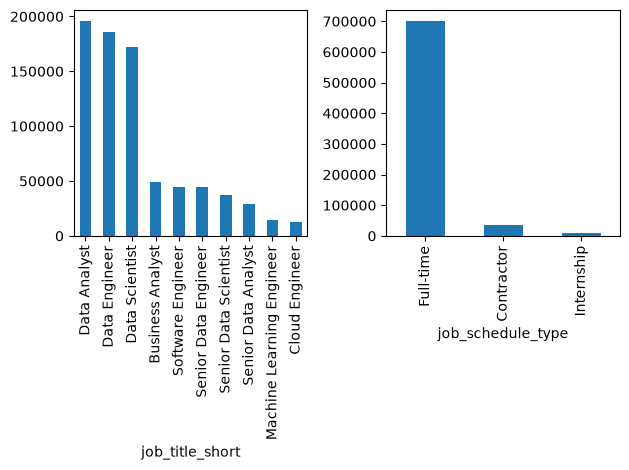

In [5]:
fig, ax = plt.subplots(1 , 2)
df['job_title_short'].value_counts().plot(kind = 'bar', ax =ax[0])
df['job_schedule_type'].value_counts().head(3).plot(kind = 'bar', ax=ax[1])
fig.tight_layout()

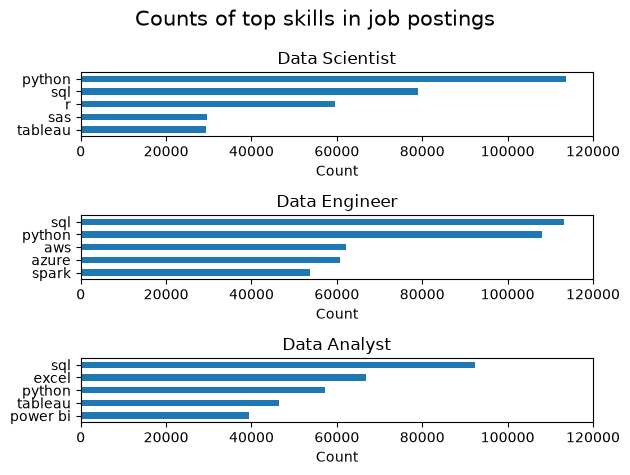

In [19]:
df_skills = df.copy()
df_skills = df_skills.explode('job_skills')
skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = skills_count.reset_index(name = 'skill_count')
df_skills_count.sort_values(by = 'skill_count', ascending = False, inplace = True)

job_titles = ['Data Scientist', 'Data Engineer', 'Data Analyst']
fig,ax = plt.subplots(3,1)

for i, job in enumerate(job_titles):
    df_plot = (df_skills_count[df_skills_count['job_title_short']== job].head(5))
    df_plot.plot(kind = 'barh', x = 'job_skills', y ='skill_count', ax = ax[i],title = job)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].set_xlabel('Count')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0,120000)

fig.suptitle('Counts of top skills in job postings', fontsize = 15)
fig.tight_layout()
